In [7]:
import numpy as np
import scipy as sp
import scipy.spatial
from collections import Counter
import matplotlib.pyplot as plt
from collections import defaultdict
import statistics
import time
from pathlib import Path
import scipy.stats
from matplotlib import pyplot
import cProfile
import pstats
import timeit

class SandPile:
    """SandPile class"""

    def __init__(self, width, height, timesteps, threshold=4):
        """Initialize a sandpile with the specified width and height."""
        
        self.timesteps = timesteps
        
        # dimensions of lattice
        self.width = width
        self.height = height

        # corner sites at the edge of the lattice
        self.corners = [(0, 0),(self.width, 0),(0, self.height),(self.width, self.height)]
        
        # threshold at which a pile will be toppled
        self.threshold = threshold

        # burn in so we only take values when statistical equilibrium is reached
        self.burn_in = int(2.365423901940756 * self.width * self.height)
        
        # initialise the grid with zeroes 
        self.grid = np.zeros((width, height), dtype="int")

        # number of grains of sand in the grid at each timestep
        self.mass_history = np.zeros(self.timesteps)

        # area is defined asnumber of sites toppled at each timestep
        self.area_history = np.zeros(self.timesteps)

        # dictionary containing the number of occurrences of each area size
        self.area_counts = defaultdict(int)

        # length is defined as the maximum manhattan distance between sites toppled at each timestep
        self.length_history = np.zeros(self.timesteps)

        # dictionary containing the number of occurrences of each length size
        self.length_counts = defaultdict(int)
        
        # number of topples at each timestep
        self.topples_history = np.zeros(self.timesteps)

        # dictionary containing the number of occurrences of each topple size
        self.topples_counts = defaultdict(int)

        # loss is defined as the number of grains of sand that "spill over the edge" in each timestep
        self.loss_history = np.zeros(self.timesteps)

        # dictionary containing the number of occurrences of each loss size
        self.loss_counts = defaultdict(int)

        # keep track of the statistics at each stage of the timestep
        self.curr_mass = 0
        self.curr_area = 0 
        self.curr_loss = 0
        self.curr_topples = 0
        self.curr_length = 0
        self.curr_time = 0

        
        # final statistics are the time and space averages of mass in the grid. time average is the average size of the pile at each site over time 
        # (meaning it is a lattice containing every site), while space average is the avereage size of all the piles at each timestep
        self.time_average = np.zeros((self.width, self.height))
        self.space_average_history = np.zeros(self.timesteps)
        

    # drops sand on a site in the lattice, increasing the number of grains in the pile at that site by 1. If site specified, the sand is dropped at the specified site,
    # otherwise a site is chosen at random for the sand to be dropped at
    
    def drop_sand(self, n=1, site = [-1,-1]):
        
        if site == [-1,-1]:
            # choose  site for the grain of sand to be dropped uniformly at random
            x_drop_site, y_drop_site = np.random.randint([0, 0], [self.width, self.height])

        else:
            x_drop_site, y_drop_site = site
        # update curr_mass
        self.grid[x_drop_site, y_drop_site] += 1
        self.curr_mass += 1

    # topples a specific site (the avalanche function will make sure that the pile at that site is at or beyond the threshold)
    def topple(self, site):
        self.curr_topples += 1
        
        # find the dimensions of the site
        x, y = site
        # subtract 4 (or self.threshold) grains from the pile
        self.grid[x,y]-= self.threshold
        
        # update curr_mass
        self.curr_mass -= self.threshold

        # add a grain of sand to neighbouring sites within the grid (and only within the grid), updating curr_mass and self.affected_sites
        if x + 1 < self.width:
            self.grid[x+1, y] += 1
            self.affected_sites.add((x+1, y))
            self.curr_mass += 1
        if x - 1 >= 0:
            self.grid[x-1, y] += 1
            self.affected_sites.add((x-1, y))
            self.curr_mass += 1
        if y + 1 < self.height:
            self.grid[x, y+1] += 1
            self.affected_sites.add((x, y+1))
            self.curr_mass += 1
        if y - 1 >= 0:
            self.grid[x, y-1] += 1
            self.affected_sites.add((x, y-1))
            self.curr_mass += 1

        

    def update_stats(self):
        self.area_counts[self.curr_area] += 1
        self.loss_counts[self.curr_loss] += 1
        self.topples_counts[self.curr_topples] += 1
        self.length_counts[self.curr_length] += 1

    # topples all sites with piles at or beyond the threshold until all piles are under the threshold
    def avalanche(self):
        has_avalanche_occurred = False
        # set of sites with piles at or above the threshold, will later contain neighbours of these toppled sites
        self.affected_sites = set(map(tuple, np.argwhere(self.grid >= self.threshold)))
        self.curr_topples = 0
        self.curr_area = 0
        self.curr_loss = 0
        self.curr_length = 0
        if self.affected_sites:
            # at the start of each avalanche there will be a maximum of one site above the threshold, since one grain of sand has been added to a previously stable grid
            self.initial_site = next(iter(self.affected_sites))
            has_avalanche_occurred = True
        
        #will store as a set the sites that have been toppled (used to store area of topple)
        self.toppled_sites = set()

        """reduce amount of operations so check for double ups"""
        while self.affected_sites:
            site = self.affected_sites.pop()
            # will add neighbours to self.affected_sites so need to check if the pile at site is actually at or above the threshold
            if self.grid[site] >= self.threshold:
                # topple site if needed and update sets
                 #self.curr_topples += 1
                 self.toppled_sites.add(site)
                 self.topple(site)

                 #if self.grid[site]>= self.threshold:
                    #self.affected_sites.add(site)
        if self.curr_time > self.burn_in and has_avalanche_occurred:
            self.find_stats()
            self.update_stats()
        
        self.area_history[self.curr_time] = self.curr_area
        self.mass_history[self.curr_time] = self.curr_mass
        self.length_history[self.curr_time] = self.curr_length
        self.loss_history[self.curr_time] = self.curr_loss
        self.topples_history[self.curr_time] = self.curr_topples
        self.space_average_history[self.curr_time] = self.curr_mass/(self.width*self.height)

    def find_stats(self):
        lengths = [0]
        for site in self.toppled_sites:
            distance_to_site = np.abs(self.initial_site[0]-site[0])+np.abs(self.initial_site[1]-site[1])
            if site in self.corners and self.initial_site not in self.corners:
                lengths.append(distance_to_site)
            else:
                lengths.append(distance_to_site+1)
        self.curr_area = len(self.toppled_sites)
        self.curr_loss = self.mass_history[self.curr_time-1]-self.curr_mass+1
        self.curr_length = int(np.max(lengths))

    
    def run(self):
        sites_to_drop = np.random.randint([0, 0], [self.width, self.height], size = (self.timesteps,2))
        for i in range(self.timesteps):
            site = sites_to_drop[i]
            self.drop_sand(site)
            self.avalanche()
            self.time_average += self.grid
            self.curr_time+=1

In [8]:
timesteps = 500000
np.random.seed(50)
curr = time.time()
sandpile_100 = SandPile(100, 100, timesteps)
sandpile_100.run()
print('Elapsed time {}'.format(time.time()-curr))

np.random.seed(50)
curr = time.time()
sandpile_90 = SandPile(90, 90, timesteps)
sandpile_90.run()
print('Elapsed time {}'.format(time.time()-curr))

np.random.seed(50)
curr = time.time()
sandpile_80 = SandPile(80, 80, timesteps)
sandpile_80.run()
print('Elapsed time {}'.format(time.time()-curr))

np.random.seed(50)
curr = time.time()
sandpile_110 = SandPile(110, 110, timesteps)
sandpile_110.run()
print('Elapsed time {}'.format(time.time()-curr))

np.random.seed(50)
curr = time.time()
sandpile_120 = SandPile(120, 120, timesteps)
sandpile_120.run()
print('Elapsed time {}'.format(time.time()-curr))

Elapsed time 426.4432508945465
Elapsed time 343.47668385505676
Elapsed time 277.85507106781006
Elapsed time 11860.314556360245
Elapsed time 591.857745885849


In [47]:
timesteps1 = 100000
np.random.seed(50)
sandpile100 = SandPile(100, 100, timesteps1)
sandpile100.run()

np.random.seed(50)
sandpile80 = SandPile(80, 80, timesteps1)
sandpile80.run()

np.random.seed(50)
sandpile60 = SandPile(60, 60, timesteps1)
sandpile60.run()

np.random.seed(50)
sandpile40 = SandPile(40, 40, timesteps1)
sandpile40.run()

np.random.seed(50)
curr = time.time()
sandpile20 = SandPile(20, 20, timesteps1)
sandpile20.run()

[  400  1600  3600  6400 10000]
Estimated Slope: 2.365423901940756


<Figure size 640x480 with 0 Axes>

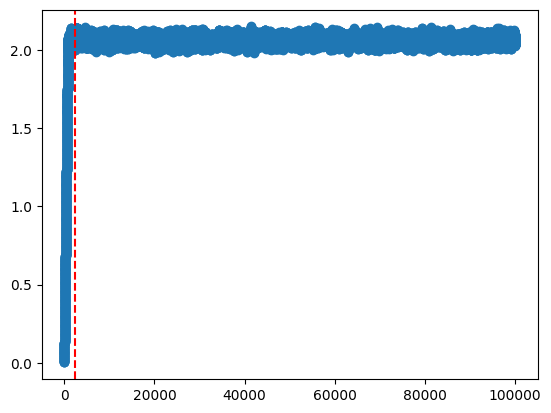

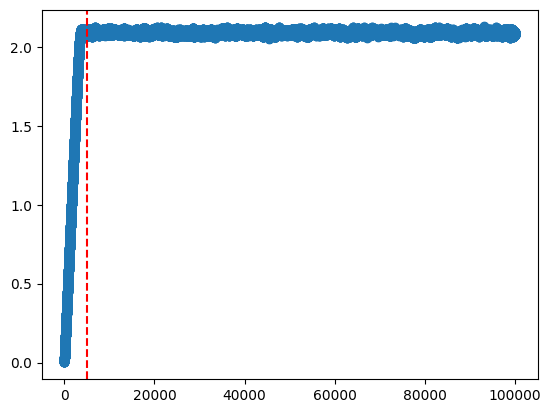

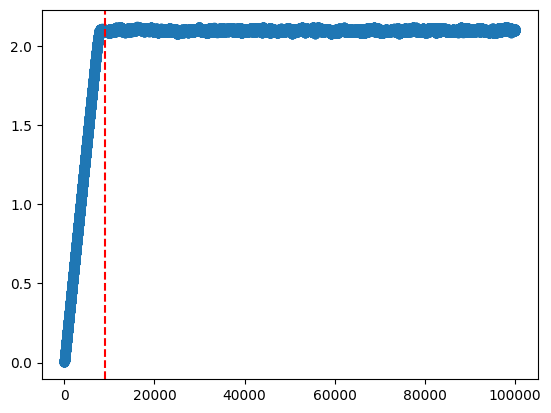

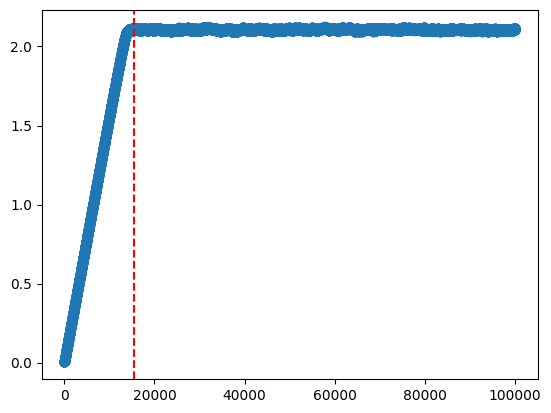

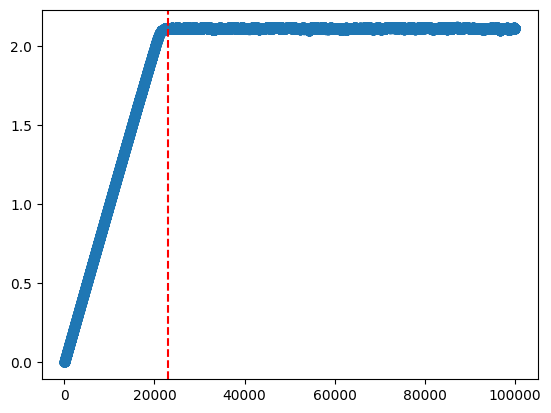

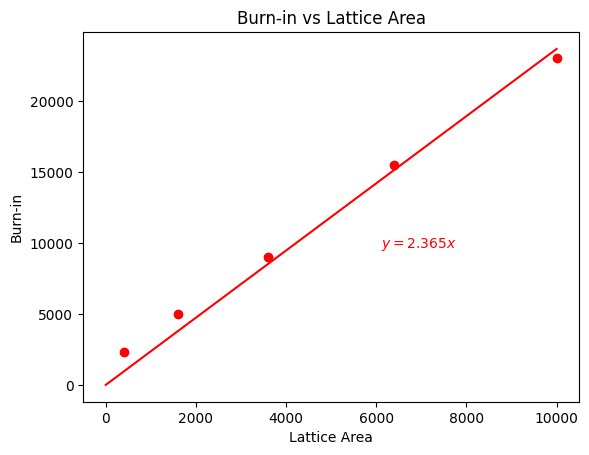

<Figure size 640x480 with 0 Axes>

In [48]:
from sklearn.linear_model import LinearRegression

x = np.arange(100000)
plt.scatter(x, sandpile20.space_average_history)
plt.axvline(x=2300, color='red', linestyle='--')
plt.savefig("20by20.png", dpi=300, bbox_inches="tight")
plt.figure()

plt.scatter(x, sandpile40.space_average_history)
plt.axvline(x=5000, color='red', linestyle='--')
plt.savefig("40by40.png", dpi=300, bbox_inches="tight")
plt.figure()

plt.scatter(x, sandpile60.space_average_history)
plt.axvline(x=9000, color='red', linestyle='--')
plt.savefig("60by60.png", dpi=300, bbox_inches="tight")
plt.figure()

plt.scatter(x, sandpile80.space_average_history)
plt.axvline(x=15500, color='red', linestyle='--')
plt.savefig("80by80.png", dpi=300, bbox_inches="tight")
plt.figure()

plt.scatter(x, sandpile100.space_average_history)
plt.axvline(x=23000, color='red', linestyle='--')
plt.savefig("100by100.png", dpi=300, bbox_inches="tight")
plt.figure()

grid_width = np.array([20, 40, 60, 80, 100])
grid_area = np.array(grid_width * grid_width)
print(grid_area)
time_to_plateau = np.array([2300, 5000, 9000, 15500, 23000])

# used to get a more precise estimate
from scipy.optimize import curve_fit

def model_func(x, a):
    return a * x

coef, _ = curve_fit(model_func, grid_area, time_to_plateau)
print(f"Estimated Slope: {coef[0]}")



x1 = np.linspace(1,10000,1000)
plt.scatter(grid_area, time_to_plateau, color = "red")
plt.plot(x1, coef[0]*x1, color = "r")
plt.text(0.6, 0.45, 
    f"$y = {coef[0]:.3f}x$",
    transform=plt.gca().transAxes,
    verticalalignment="top", color="red")
plt.xlabel("Lattice Area")
plt.ylabel("Burn-in")
plt.title("Burn-in vs Lattice Area")
plt.savefig("burnin.png", dpi=300, bbox_inches="tight")
plt.figure()

<Figure size 640x480 with 0 Axes>

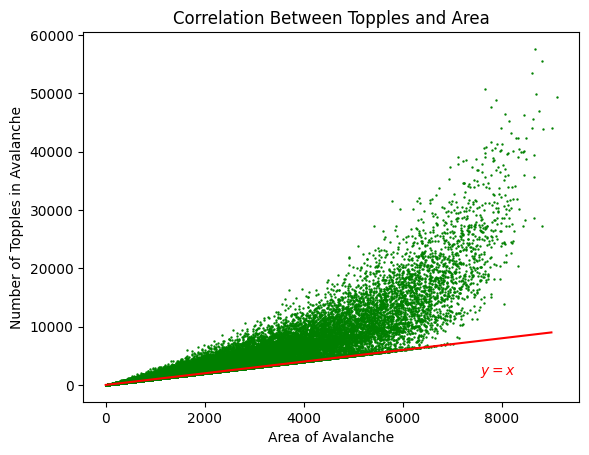

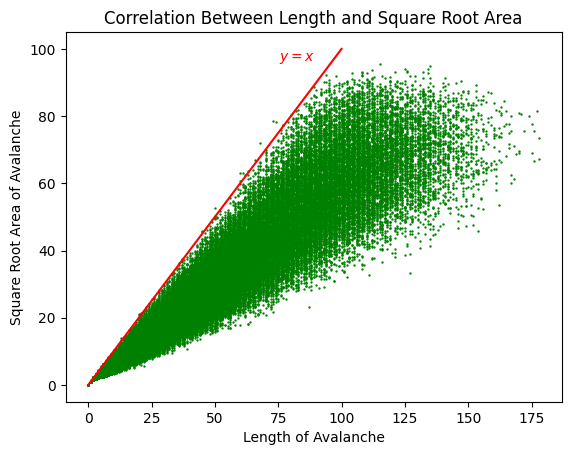

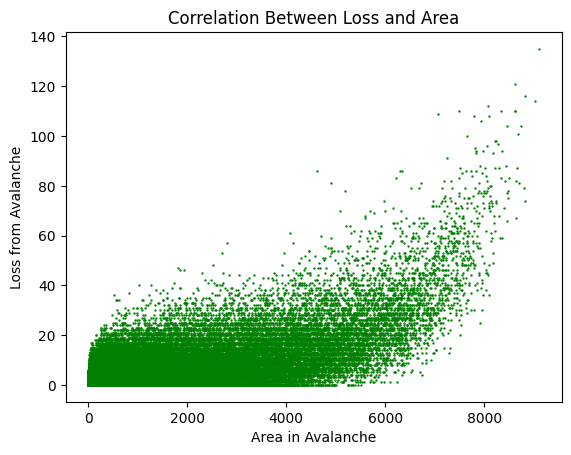

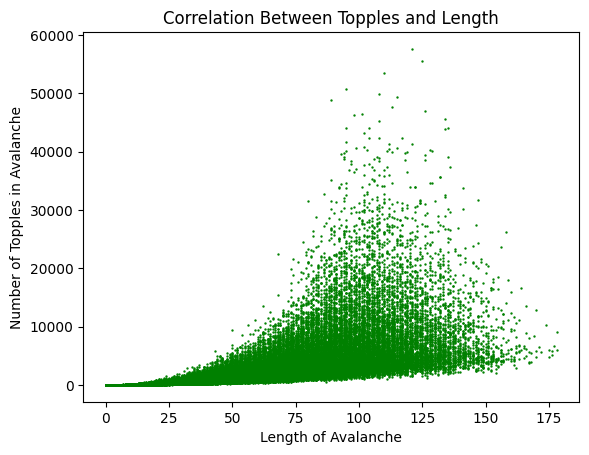

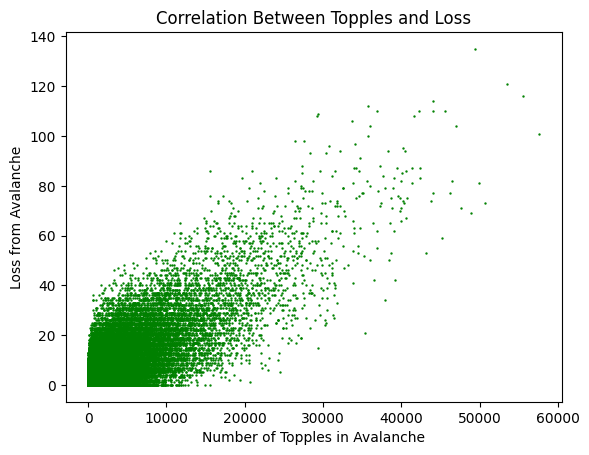

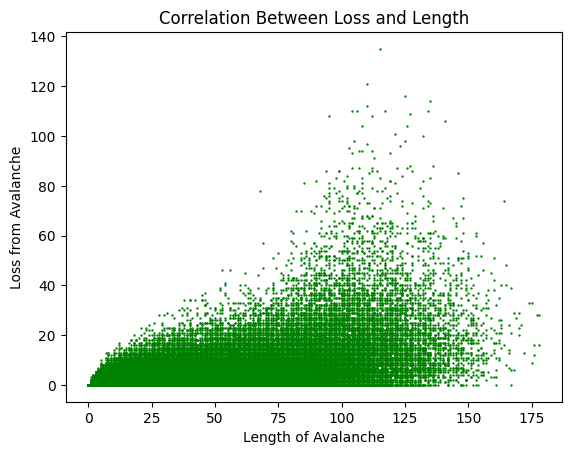

<Figure size 640x480 with 0 Axes>

In [11]:
def correlation_plot(x, y):
    plt.scatter(x, y, s=0.5, color = "g")

area_history_post_burn_in = sandpile_100.area_history[sandpile_100.burn_in:]
topples_history_post_burn_in = sandpile_100.topples_history[sandpile_100.burn_in:]
length_history_post_burn_in = sandpile_100.length_history[sandpile_100.burn_in:]
loss_history_post_burn_in = sandpile_100.loss_history[sandpile_100.burn_in:]


x_vals = np.linspace(0,9000,200)
correlation_plot(area_history_post_burn_in, topples_history_post_burn_in)
plt.title("Correlation Between Topples and Area")
plt.text(0.8, 0.1, 
     f"$y = x$",
     transform=plt.gca().transAxes,  # positions relative to axes (0-1)
     verticalalignment="top", color = "red")
plt.plot(x_vals, x_vals, color = "r")
plt.xlabel("Area of Avalanche")
plt.ylabel("Number of Topples in Avalanche")
plt.savefig("corrta.png", dpi=300, bbox_inches="tight")
plt.figure()

x_vals1 = np.linspace(0,100,200)
correlation_plot(length_history_post_burn_in, np.sqrt(area_history_post_burn_in))
plt.plot(x_vals1, x_vals1, color = "r")
plt.text(0.43, 0.95, 
     f"$y = x$",
     transform=plt.gca().transAxes,  # positions relative to axes (0-1)
     verticalalignment="top", color = "red")

plt.title("Correlation Between Length and Square Root Area")
plt.xlabel("Length of Avalanche")
plt.ylabel("Square Root Area of Avalanche")
plt.savefig("corrlea.png", dpi=300, bbox_inches="tight")
plt.figure()

correlation_plot(area_history_post_burn_in, loss_history_post_burn_in)
plt.title("Correlation Between Loss and Area")
plt.xlabel("Area in Avalanche")
plt.ylabel("Loss from Avalanche")
plt.savefig("corrloa.png", dpi=300, bbox_inches="tight")
plt.figure()


correlation_plot(length_history_post_burn_in, topples_history_post_burn_in)
plt.title("Correlation Between Topples and Length")
plt.xlabel("Length of Avalanche")
plt.ylabel("Number of Topples in Avalanche")
plt.savefig("corrtle.png", dpi=300, bbox_inches="tight")
plt.figure()


correlation_plot(topples_history_post_burn_in, loss_history_post_burn_in)
plt.title("Correlation Between Topples and Loss")
plt.xlabel("Number of Topples in Avalanche")
plt.ylabel("Loss from Avalanche")
plt.savefig("corrtlo.png", dpi=300, bbox_inches="tight")
plt.figure()


correlation_plot(length_history_post_burn_in, loss_history_post_burn_in)
plt.title("Correlation Between Loss and Length")
plt.xlabel("Length of Avalanche")
plt.ylabel("Loss from Avalanche")
plt.savefig("corrlelo.png", dpi=300, bbox_inches="tight")
plt.figure()





In [35]:
"""Plots for 100"""
def fitted_log_log_plot(x, y, upper_bound):
    log_x = np.log(x)
    log_y = np.log(y)
    x_vals = np.linspace(0, max(log_x), 200)
    plt.scatter(log_x, log_y, s = 3, color = "green")
    a, b = np.polyfit(log_x[:upper_bound], log_y[:upper_bound], deg = 1)
    plt.plot(x_vals, a*x_vals + b, color = "red", lw = 0.8)
    plt.text(0.2, 0.9, 
    f"$y = {a:.3f}x + {b:.3f}$",
    transform=plt.gca().transAxes,
    verticalalignment="top", color="red")

/var/folders/gr/r5hjgt_91137fyzl9b00tl700000gn/T/ipykernel_9090/1351643201.py:39: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


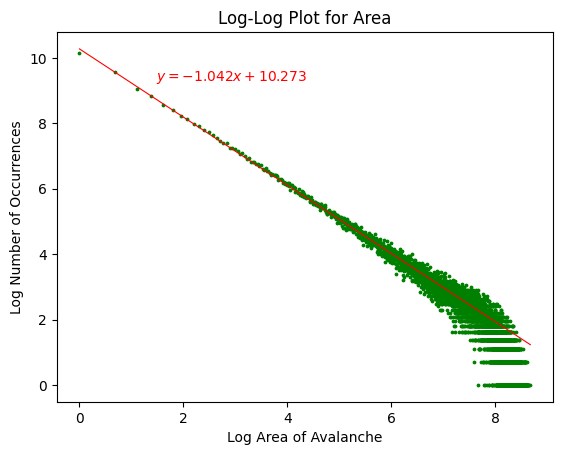

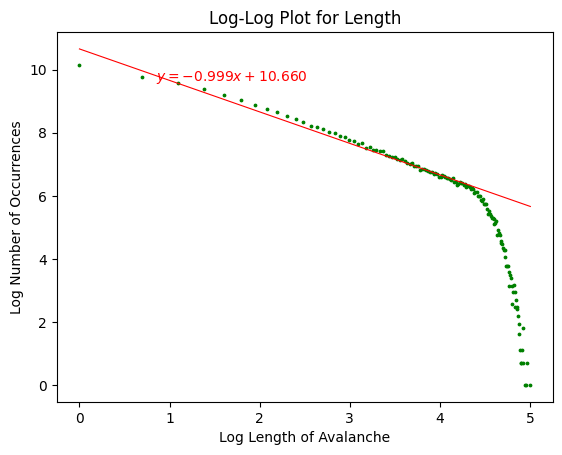

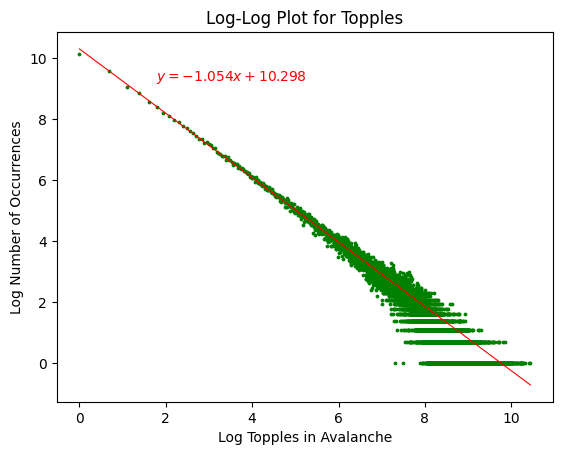

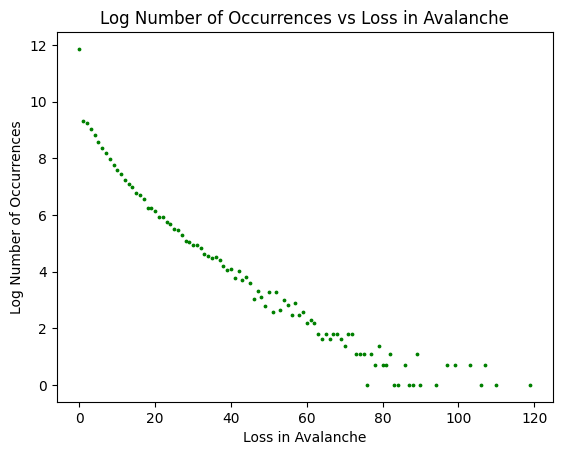

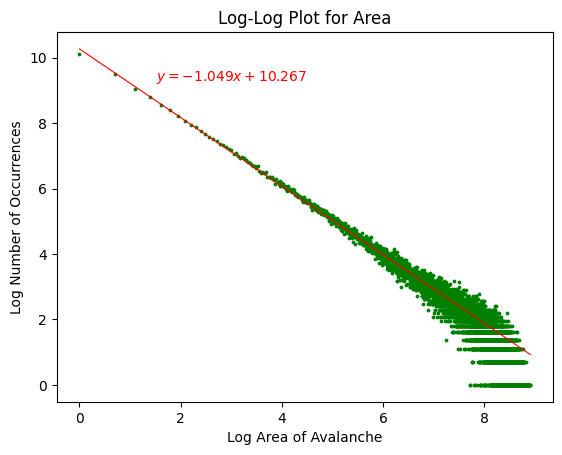

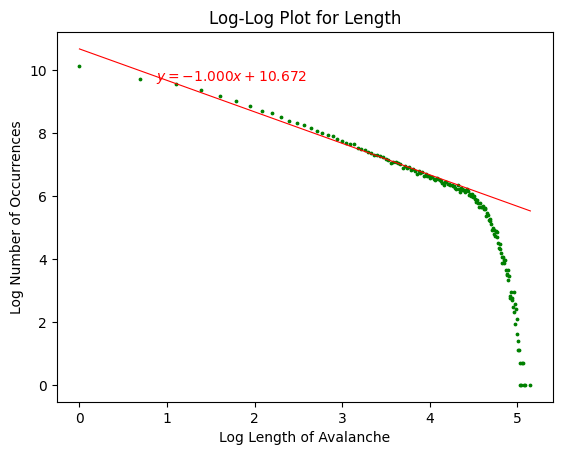

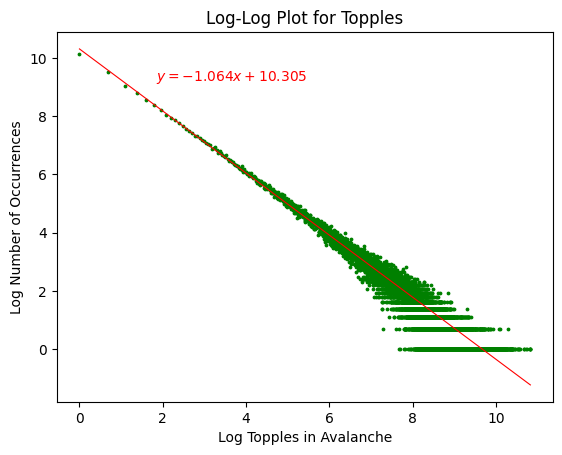

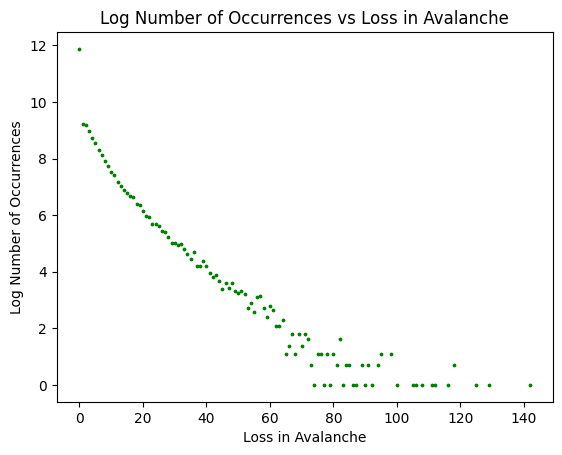

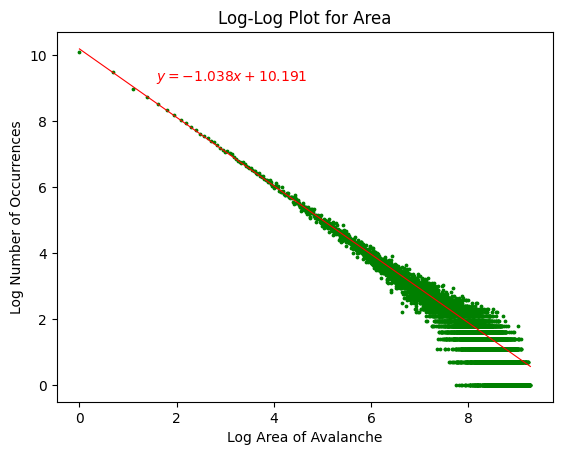

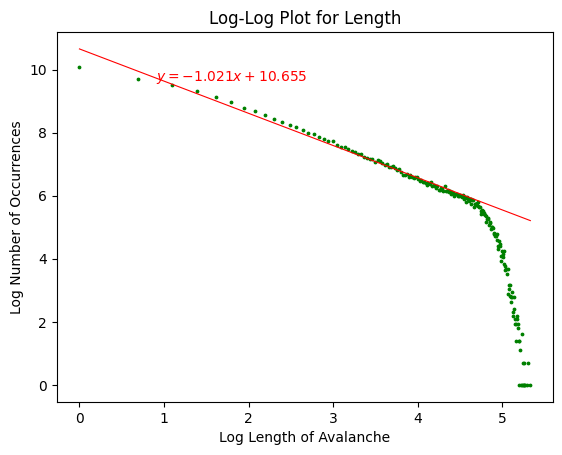

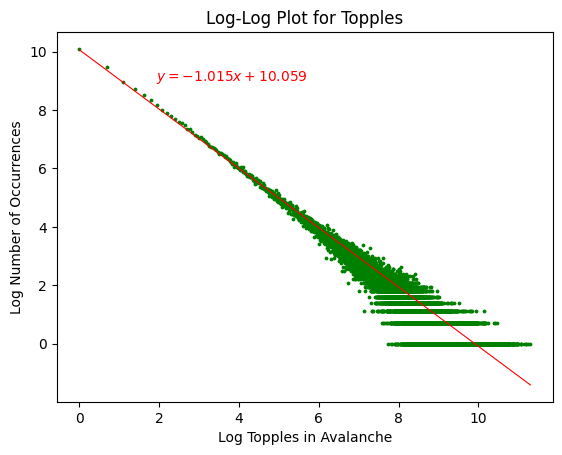

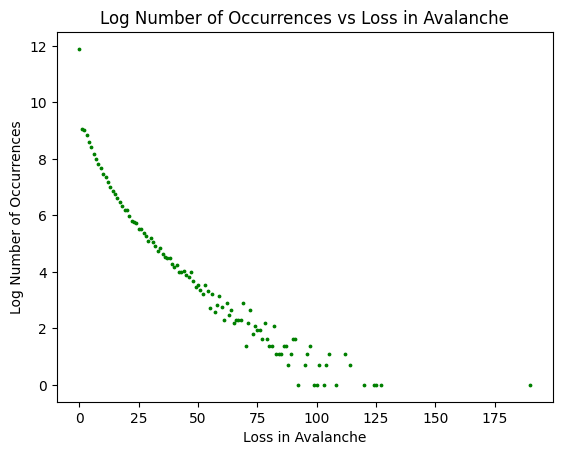

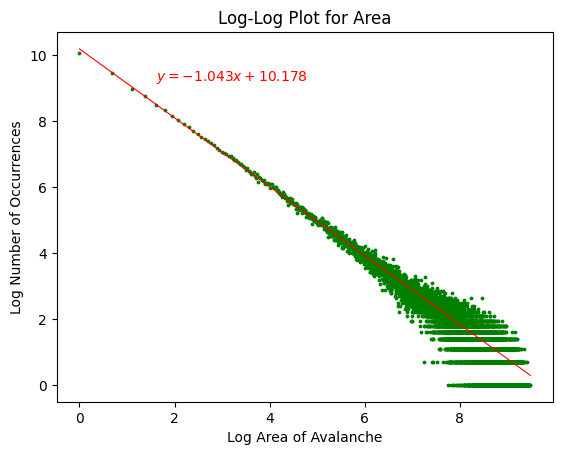

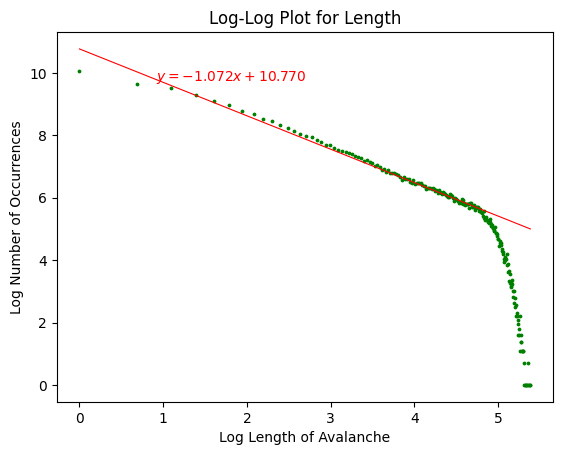

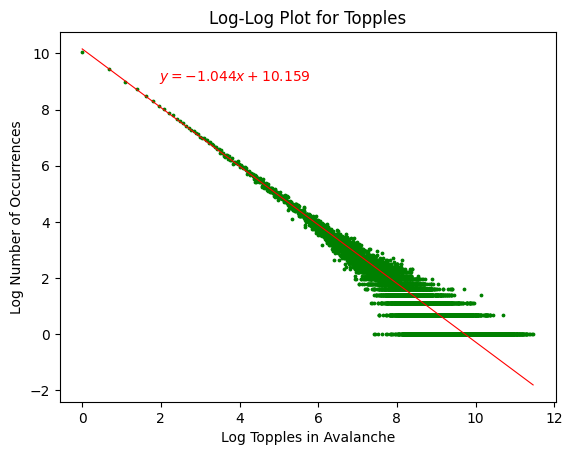

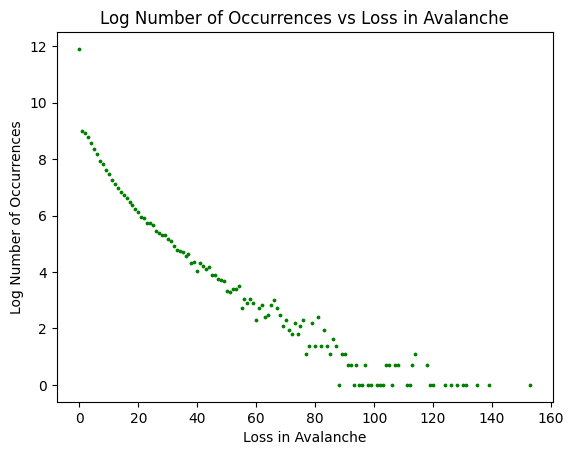

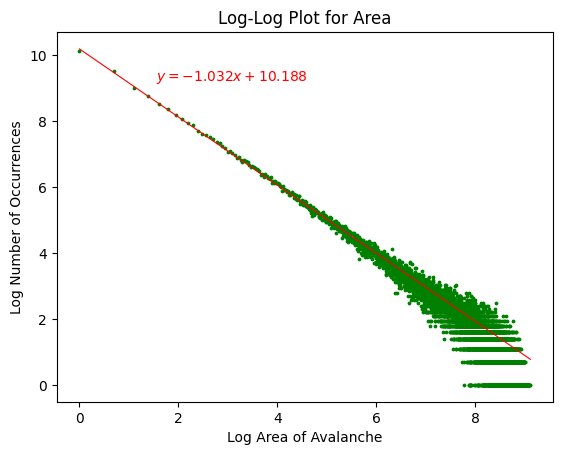

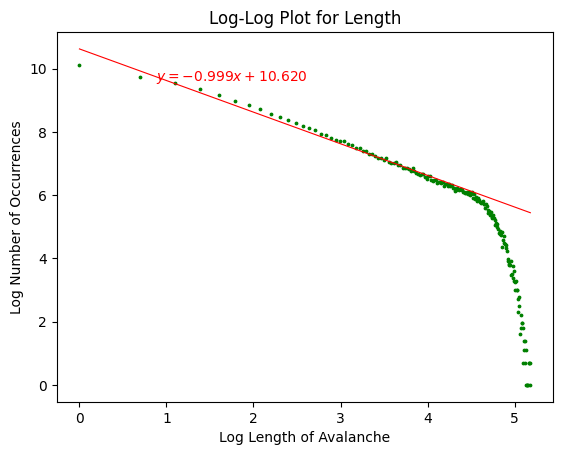

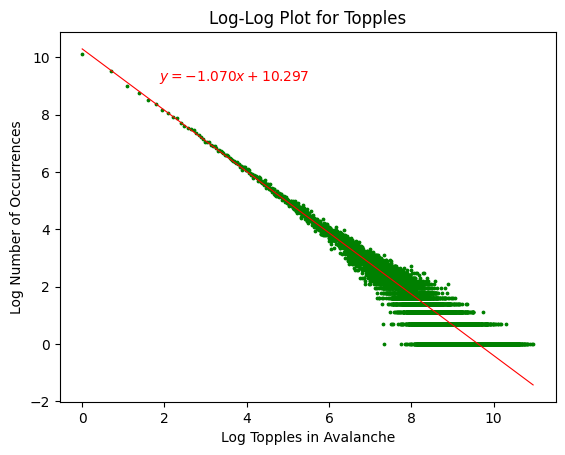

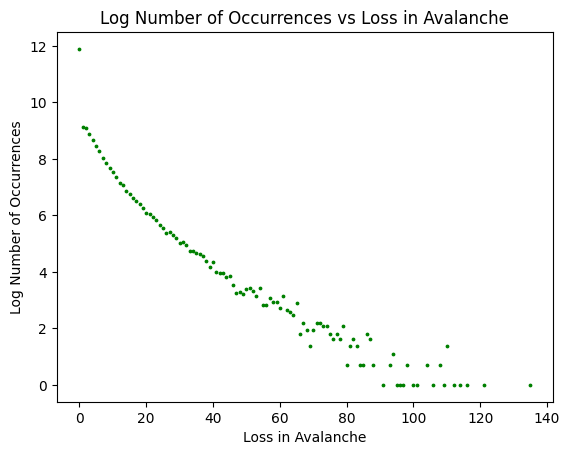

<Figure size 640x480 with 0 Axes>

In [36]:
def ll_plots(sandpile):
    no_sites = sandpile.width * sandpile.height 
    areas = np.array(list(sandpile.area_counts.keys()))
    area_occs = np.array(list(sandpile.area_counts.values()))
    
    lengths = np.array(list(sandpile.length_counts.keys()))
    length_occs = np.array(list(sandpile.length_counts.values()))
    
    losses = np.array(list(sandpile.loss_counts.keys()))
    loss_occs = np.array(list(sandpile.loss_counts.values()))
    
    topples = np.array(list(sandpile.topples_counts.keys()))
    topples_occs = np.array(list(sandpile.topples_counts.values()))

    
    fitted_log_log_plot(areas, area_occs, int(no_sites/300))
    plt.xlabel("Log Area of Avalanche")
    plt.ylabel("Log Number of Occurrences")
    plt.title("Log-Log Plot for Area")
    plt.savefig("loglogarea.png", dpi=300, bbox_inches="tight")
    plt.figure()
    fitted_log_log_plot(lengths, length_occs, int(no_sites/300))
    plt.xlabel("Log Length of Avalanche")
    plt.ylabel("Log Number of Occurrences")
    plt.title("Log-Log Plot for Length")
    plt.savefig("logloglength.png", dpi=300, bbox_inches="tight")
    plt.figure()
    fitted_log_log_plot(topples, topples_occs, int(no_sites/300))
    plt.xlabel("Log Topples in Avalanche")
    plt.ylabel("Log Number of Occurrences")
    plt.title("Log-Log Plot for Topples")
    plt.savefig("loglogtopples.png", dpi=300, bbox_inches="tight")
    plt.figure()
    plt.scatter(losses, np.log(np.maximum(loss_occs, 1)), s=3, color = "g")
    plt.xlabel("Loss in Avalanche")
    plt.ylabel("Log Number of Occurrences")
    plt.title("Log Number of Occurrences vs Loss in Avalanche")
    plt.savefig("loglosses.png", dpi=300, bbox_inches="tight")
    plt.figure()

ll_plots(sandpile_80)
ll_plots(sandpile_90)
ll_plots(sandpile_110)
ll_plots(sandpile_120)
ll_plots(sandpile_100)

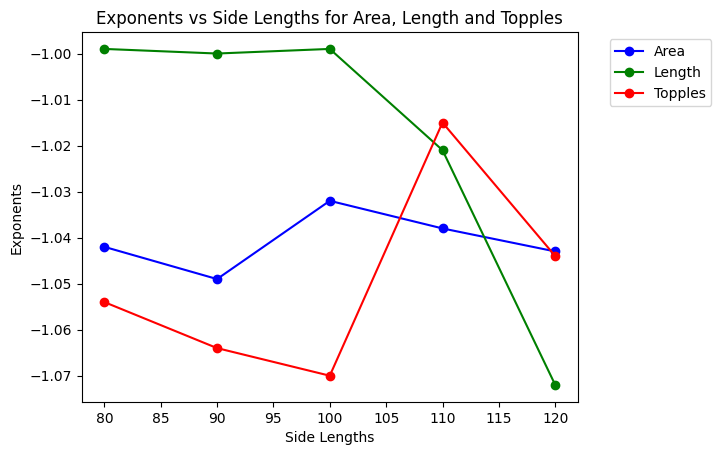

In [35]:
side_lengths = np.array([80,90,100,110,120])
area_exponents = np.array([-1.042, -1.049, -1.032, -1.038, -1.043])
length_exponents = np.array([-0.999, -1.000, -0.999, -1.021, -1.072])
topples_exponents = np.array([-1.054, -1.064, -1.070, -1.015, -1.044])


x = np.linspace(80, 120, 100)
plt.plot(side_lengths, area_exponents, color = "b", label = "Area", marker='o',)
plt.plot(side_lengths, length_exponents, color = "g", label = "Length", marker='o',)
plt.plot(side_lengths, topples_exponents, color = "r", label = "Topples", marker='o',)

plt.xlabel("Side Lengths")
plt.ylabel("Exponents")
plt.title("Exponents vs Side Lengths for Area, Length and Topples")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("exponents.png", dpi=300, bbox_inches="tight")

In [15]:
import piecewise_regression
def pw_fit(x,y):
    pw_fit = piecewise_regression(np.log(x), np.log(np.maximum(y,1)), n_breakpoints = 1, tolerance = 1e-3)
    params - pw_fit.get_params()
    bp = params_area['breakpoint1']
    fitted_log_log_plot(x, y, int(np.exp(bp)))



In [17]:
# fits log-log plots for area, topples and length of sandpile cutting off extreme values
def pw_reg_log_log_plots(sandpile):
    areas = np.array(list(sandpile.area_counts.keys()))
    area_occs = np.array(list(sandpile.area_counts.values()))
    area_freqs = area_occs/sum(area_occs)
    
    lengths = np.array(list(sandpile.length_counts.keys()))
    length_occs = np.array(list(sandpile.length_counts.values()))
    length_freqs = length_occs/sum(length_occs)
    
    losses = np.array(list(sandpile.loss_counts.keys()))
    loss_occs = np.array(list(sandpile.loss_counts.values()))
    loss_freqs = loss_occs/sum(loss_occs)
    
    topples = np.array(list(sandpile.topples_counts.keys()))
    topples_occs = np.array(list(sandpile.topples_counts.values()))
    topples_freqs = topples_occs/sum(topples_occs)

    pw_fit_area = piecewise_regression.Fit(np.log(areas), np.log(area_occs), n_breakpoints=1, start_values=[np.log(areas[3*len(areas)//4])], tolerance=1e-3)
    params_area = pw_fit_area.get_params()
    if params_area['converged'] is False:
        bp_area = len(areas)
        fitted_log_log_plot(areas, area_occs, bp_area)
    else:
        bp_area = params_area['breakpoint1']
        fitted_log_log_plot(areas, area_occs, int(np.exp(bp_area)))
    plt.xlabel("Log Area")
    plt.ylabel("Log Number of Occurrences")
    plt.title("Log Number of Occurrences vs Log Area")
    plt.figure()

    pw_fit_length = piecewise_regression.Fit(np.log(lengths), np.log(length_occs), n_breakpoints=1, start_values=[np.log(lengths[3*len(lengths)//4])])
    params_length = pw_fit_length.get_params()
    if params_length['converged'] is False:
        bp_length = len(lengths)
        fitted_log_log_plot(lengths, length_occs, bp_length)
    else:
        bp_length = params_length['breakpoint1'] 
        fitted_log_log_plot(lengths, length_occs, int(np.exp(bp_length)))
    plt.xlabel("Log Length")
    plt.ylabel("Log Number of Occurrences")
    plt.title("Log Number of Occurrences vs Log Length")
    plt.figure()

    pw_fit_topples = piecewise_regression.Fit(np.log(topples), np.log(topples_occs), n_breakpoints=1, start_values=[np.log(topples[3*len(topples)//4])])
    params_topples = pw_fit_topples.get_params()
    if params_topples['converged'] is False:
        bp_topples = len(topples)
        fitted_log_log_plot(topples, topples_occs, bp_topples)
    else:
        bp_topples = params_topples['breakpoint1']
        fitted_log_log_plot(topples, topples_occs, int(np.exp(bp_topples)))
    plt.xlabel("Log Topples")
    plt.ylabel("Log Number of Occurrences")
    plt.title("Log Number of Occurrences vs Log Topples")
    plt.figure()

In [18]:
def find_mask20(x, y):
    ransac = RANSACRegressor(random_state = 20)
    ransac.fit(np.log(x).reshape(-1,1), np.log(np.maximum(y, 1)))
    inlier_mask = ransac.inlier_mask_
    return inlier_mask

def find_mask40(x, y):
    ransac = RANSACRegressor(random_state = 40)
    ransac.fit(np.log(x).reshape(-1,1), np.log(np.maximum(y, 1)))
    inlier_mask = ransac.inlier_mask_
    return inlier_mask

In [19]:
from sklearn.linear_model import RANSACRegressor

def ransac_log_log_plots(sandpile):
    areas = np.array(list(sandpile.area_counts.keys()))
    area_occs = np.array(list(sandpile.area_counts.values()))
    area_freqs = area_occs/sum(area_occs)
    
    lengths = np.array(list(sandpile.length_counts.keys()))
    length_occs = np.array(list(sandpile.length_counts.values()))
    length_freqs = length_occs/sum(length_occs)
    
    losses = np.array(list(sandpile.loss_counts.keys()))
    loss_occs = np.array(list(sandpile.loss_counts.values()))
    loss_freqs = loss_occs/sum(loss_occs)
    
    topples = np.array(list(sandpile.topples_counts.keys()))
    topples_occs = np.array(list(sandpile.topples_counts.values()))
    topples_freqs = topples_occs/sum(topples_occs)

    area_mask = find_mask40(areas, area_occs)
    length_mask = find_mask40(lengths, length_occs)
    topples_mask = find_mask40(topples, topples_occs)

    # i then plotted log-log plots of area[mask] vs area_occs[mask] etc.
    

    


    